# Inverse Design: Predicting Impurity Distance Matrices

This notebook trains two models that solve the **inverse scattering** problem for 7-AGNR nanoribbons:

| Model | Module | Encoder | Output |
|-------|--------|---------|--------|
| **CNN** (§2) | `inverse_model.py` | 1D Conv + ResBlocks | 10×10 distance matrix |
| **Patched Transformer** (§4) | `patched_transformer_model.py` | 1D Patching + Self-Attention | 10×10 distance matrix |

Both models map a normalised transmission spectrum $T(E) \in \mathbb{R}^{200}$ to a $10 \times 10$ impurity distance matrix, trained with **MSE + physics-informed Misfit Loss**.

> For a detailed architecture explanation see [`patched_transformer_explanation.md`](patched_transformer_explanation.md) and [`inverse_model_explanation.md`](inverse_model_explanation.md).

In [23]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from inverse_model import InverseGNRDataset, InverseModel, train_inverse_model, visualize_prediction

## 1. Load Data
We load the pristine transmission for normalisation. The `InverseGNRDataset` reads `manifest_agnr.csv`, filters for concentration $\leq 10$, and constructs on-the-fly target labels as $10 \times 10$ **impurity distance matrices** — the diagonal stores within-cell site positions and the off-diagonal stores pairwise Euclidean distances between impurities (zero-padded when `conc < max_conc`).

In [24]:
# Ensure your transmission results directory is correct here
DATA_DIR = os.path.expanduser('~/transmission_results')

# Load pristine transmission - adjust path if necessary 
try:
    pristine = np.load('../../data/raw/transmission_results/pristine.npy')[:200]
except:
    print("Warning: Pristine file not found. Pre-computing or using array of ones for test.")
    pristine = np.ones(200)

dataset = InverseGNRDataset(
    manifest_file='manifest_agnr.csv',
    root_dir=DATA_DIR,
    pristine=pristine,
    max_conc=10,
    spectrum_length=200
)

print(f"Total items in dataset: {len(dataset)}")

if len(dataset) > 0:
    x, y = dataset[0]
    print(f"Input shape  (Spectrum T(E)):     {x.shape}") 
    print(f"Output shape (Distance Matrix D): {y.shape}")

Loaded InverseGNRDataset with 50000 samples (conc <= 10)
Total items in dataset: 50000
Input shape  (Spectrum T(E)):     torch.Size([200])
Output shape (Distance Matrix D): torch.Size([10, 10])


## 2. Train CNN Model
The CNN encoder-decoder is trained with **MSE loss** on the flattened distance matrix, plus a **Misfit Loss** that provides a physics-informed constraint. The Misfit Loss estimates the impurity concentration from the predicted matrix (via row-wise L2 norms) and penalises predictions that are inconsistent with the input spectrum.

In [28]:
if len(dataset) > 0:
    model, train_losses, val_losses = train_inverse_model(
        dataset=dataset,
        num_epochs=50,
        batch_size=16,
        lr=7e-4,
        misfit_weight=0.05 # Weights the physics-informed constraint
    )
else:
    print("Dataset is empty. Check your data path and CSV.")

Training on device: cpu
Pre-computing reference spectra for Misfit Loss...
Epoch 001/50 | Train Loss: 218.4269 | Val Loss: 180.1116
Epoch 002/50 | Train Loss: 179.0650 | Val Loss: 173.3824
Epoch 003/50 | Train Loss: 173.4957 | Val Loss: 176.5787
Epoch 004/50 | Train Loss: 170.8464 | Val Loss: 193.9032
Epoch 005/50 | Train Loss: 168.8860 | Val Loss: 175.7325
Epoch 006/50 | Train Loss: 167.5755 | Val Loss: 167.6246
Epoch 007/50 | Train Loss: 166.4920 | Val Loss: 167.5331
Epoch 008/50 | Train Loss: 165.9011 | Val Loss: 166.3344
Epoch 009/50 | Train Loss: 164.6092 | Val Loss: 168.2595
Epoch 010/50 | Train Loss: 164.0448 | Val Loss: 176.1627
Epoch 011/50 | Train Loss: 163.3043 | Val Loss: 166.2812
Epoch 012/50 | Train Loss: 163.0258 | Val Loss: 170.5713
Epoch 013/50 | Train Loss: 162.5017 | Val Loss: 189.8873
Epoch 014/50 | Train Loss: 161.8973 | Val Loss: 172.9250
Epoch 015/50 | Train Loss: 161.4190 | Val Loss: 163.4204
Epoch 016/50 | Train Loss: 161.2438 | Val Loss: 168.7486
Epoch 017/50 

KeyboardInterrupt: 

## 3. Visualise CNN Results
The learning curve shows training vs. validation loss (MSE + Misfit). The prediction visualisation displays the input spectrum alongside the true and predicted $10 \times 10$ distance matrices.

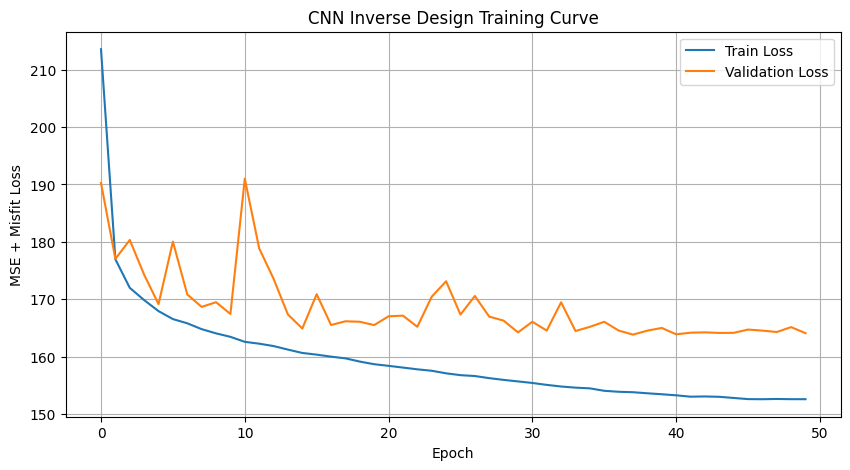

In [26]:
if 'train_losses' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE + Misfit Loss')
    plt.title('CNN Inverse Design Training Curve')
    plt.legend()
    plt.grid()
    plt.show()

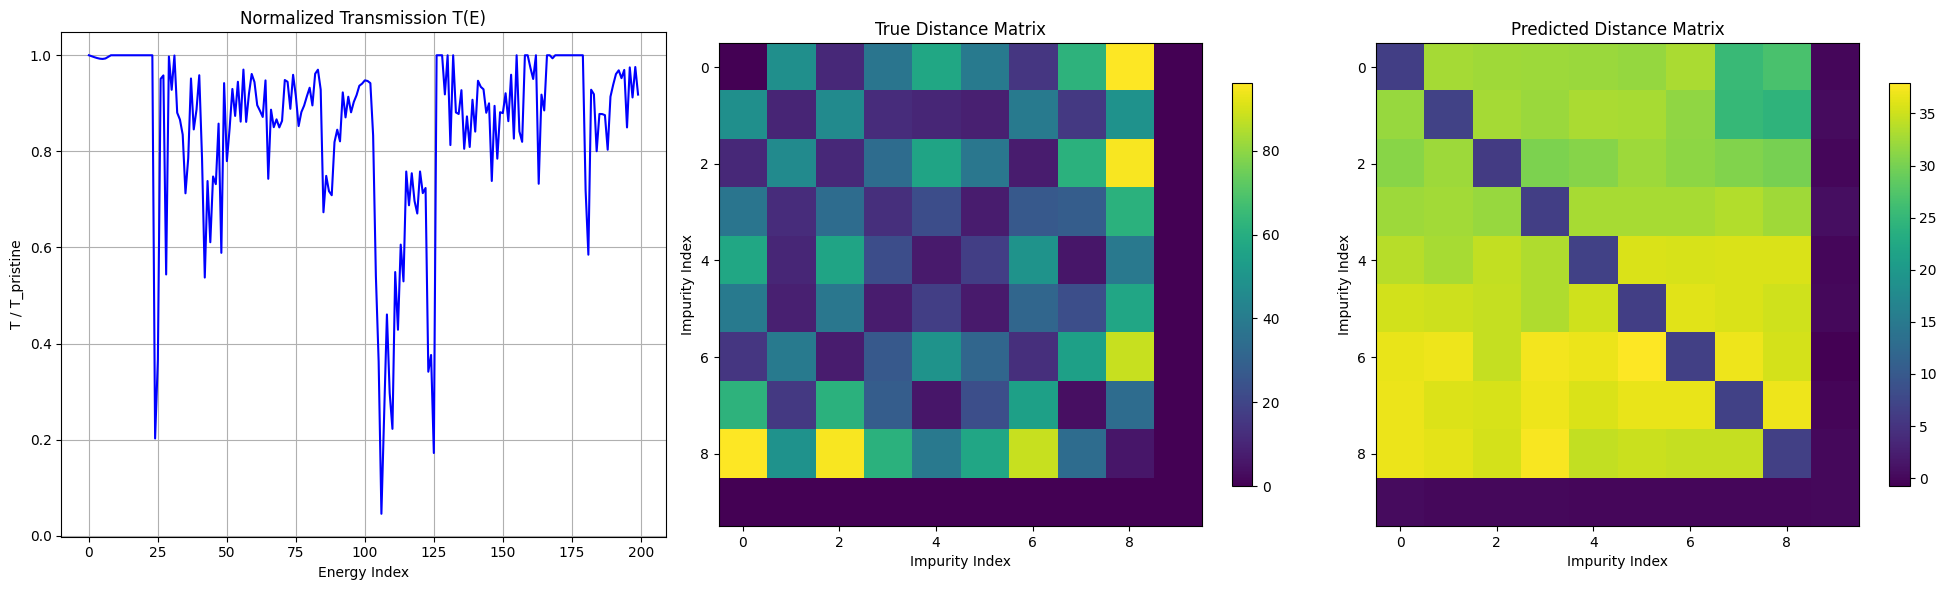

In [27]:
if 'model' in locals():
    # Test random index
    random_idx = np.random.randint(0, len(dataset))
    visualize_prediction(model, dataset, idx=random_idx)

---
## 4. Patched Transformer Model

The **1D-Patched Transformer** replaces the CNN encoder with a Transformer that operates on non-overlapping patches of the spectrum.

| Stage | Operation | Shape |
|-------|-----------|-------|
| Patch Embedding | `Conv1d(1→64, k=10, s=10)` + positional encoding | `[B, 20, 64]` |
| Transformer Encoder | 3× pre-norm layers, 4 heads, GELU | `[B, 20, 64]` |
| 1×1 Conv Bottleneck | 64→128→32 channels | `[B, 32, 20]` |
| FC Decoder | flatten → 256 (BN+ReLU) → 100 | `[B, 100]` |

**Why patching?** A standard Transformer on 200 raw points computes a $200 \times 200$ attention matrix per layer. Patching into 20 tokens of 10 energy bins shrinks this to $20 \times 20$, and each patch acts as a local feature extractor for resonance shapes.

**Interpretability:** The `extract_attention_weights()` utility hooks into the self-attention layers and returns per-head $20 \times 20$ attention maps, letting us verify which energy bands the model couples.

> Full architecture details: [`patched_transformer_explanation.md`](patched_transformer_explanation.md)

In [9]:
from patched_transformer_model import PatchedInverseModel, train_patched_model, visualize_prediction as pt_visualize

### 4.1 Train the Patched Transformer
Uses the same `dataset` loaded in Section 1, with MSE loss + Misfit Loss.

In [ ]:
if len(dataset) > 0:
    pt_model, pt_train_losses, pt_val_losses = train_patched_model(
        dataset=dataset,
        num_epochs=25,
        batch_size=16,
        lr=7e-4,
        misfit_weight=0,
        patch_size=20,
        embed_dim=64,
        num_heads=4,
        depth=3
    )
else:
    print("Dataset is empty. Check your data path and CSV.")

Training on device: cpu
Model parameters: 354,692
Pre-computing reference spectra for Misfit Loss...
   [Epoch 1] Batch 20/2500
   [Epoch 1] Batch 40/2500
   [Epoch 1] Batch 60/2500
   [Epoch 1] Batch 80/2500
   [Epoch 1] Batch 100/2500
   [Epoch 1] Batch 120/2500
   [Epoch 1] Batch 140/2500
   [Epoch 1] Batch 160/2500
   [Epoch 1] Batch 180/2500
   [Epoch 1] Batch 200/2500
   [Epoch 1] Batch 220/2500
   [Epoch 1] Batch 240/2500
   [Epoch 1] Batch 260/2500
   [Epoch 1] Batch 280/2500
   [Epoch 1] Batch 300/2500
   [Epoch 1] Batch 320/2500
   [Epoch 1] Batch 340/2500
   [Epoch 1] Batch 360/2500
   [Epoch 1] Batch 380/2500
   [Epoch 1] Batch 400/2500
   [Epoch 1] Batch 420/2500
   [Epoch 1] Batch 440/2500
   [Epoch 1] Batch 460/2500
   [Epoch 1] Batch 480/2500
   [Epoch 1] Batch 500/2500
   [Epoch 1] Batch 520/2500
   [Epoch 1] Batch 540/2500
   [Epoch 1] Batch 560/2500
   [Epoch 1] Batch 580/2500
   [Epoch 1] Batch 600/2500
   [Epoch 1] Batch 620/2500
   [Epoch 1] Batch 640/2500
   [Epo

### 4.2 Loss Curves

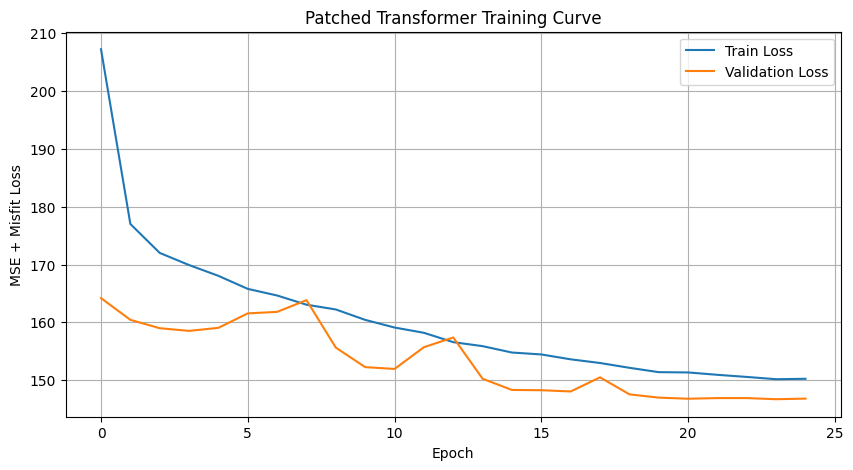

In [19]:
if "pt_train_losses" in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(pt_train_losses, label="Train Loss")
    plt.plot(pt_val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE + Misfit Loss")
    plt.title("Patched Transformer Training Curve")
    plt.legend()
    plt.grid()
    plt.show()

### 4.3 Predictions + Attention Heatmap
Visualise a random sample: the input spectrum, true and predicted distance matrices, and the self-attention heatmap showing which energy bands the model couples.

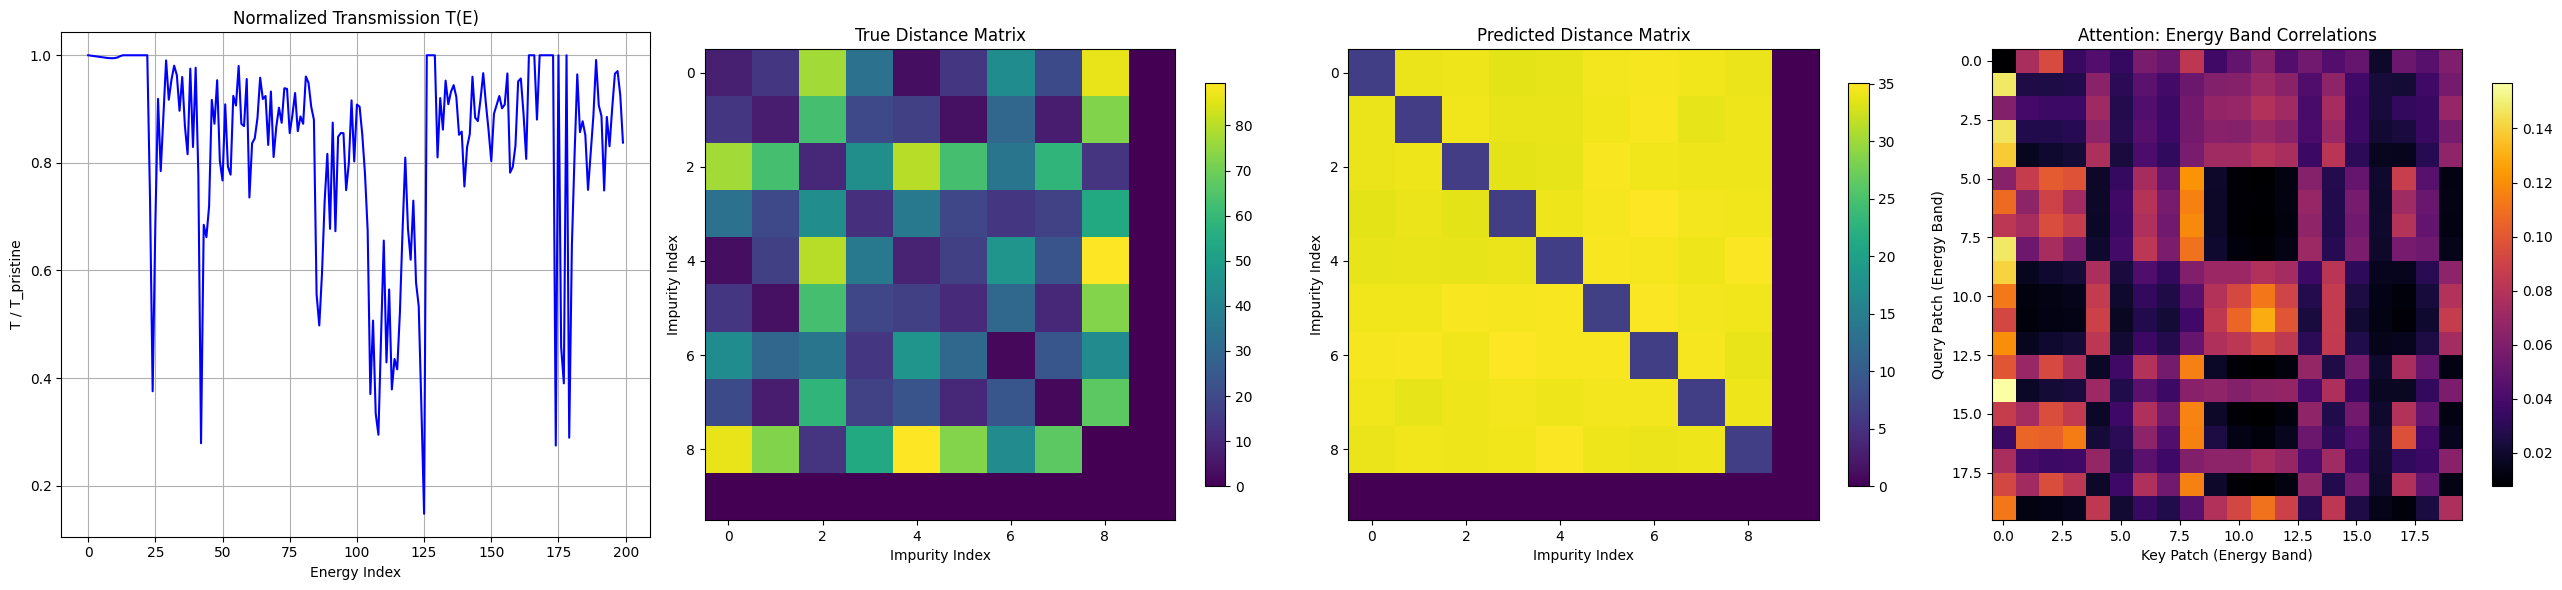

In [22]:
if "pt_model" in locals():
    random_idx = np.random.randint(0, len(dataset))
    pt_visualize(pt_model, dataset, idx=random_idx)